# Ablation 04: Iterative Refinement

Evaluates GQMoE with n_iterations ∈ {1, 2, 3, 4} to show that multiple passes of GlobalSummary → QuantumRouter → MoE → NodeUpdater progressively enrich node representations and improve classification accuracy.

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')
DRIVE_DIR    = '/content/drive/MyDrive/GQMoE'
ABLATION_DIR = f'{DRIVE_DIR}/ablations/04_iterative_refinement'
DATA_DIR     = f'{DRIVE_DIR}/data'
os.makedirs(ABLATION_DIR, exist_ok=True)


Mounted at /content/drive


In [ ]:
requirements_path = f"{DRIVE_DIR}/requirements.txt"
!pip install -r "{requirements_path}"

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 11.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.2/828.2 kB 30.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.9/306.9 kB 13.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 76

In [ ]:
import os, json, math, torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import knn_graph, global_mean_pool, GlobalAttention, GCNConv, GATConv, SAGEConv, GINConv
from torchvision import transforms
from sklearn.metrics import roc_auc_score
import pennylane as qml
torch.manual_seed(42); np.random.seed(42)


In [ ]:
base_config = {
    "file_path": f"{DATA_DIR}/retinamnist.npz",
    "patch_size": 7, "k_neighbors": 3, "batch_size": 32,
    "n_qubits": 8, "n_layers": 2, "expert_hidden": 64, "expert_out": 128,
    "top_k": 2, "n_classes": 5, "clf_hidden": 256, "dropout": 0.3,
    "epochs": 50, "warmup_epochs": 5, "lr": 1e-3, "weight_decay": 1e-4,
    "aug_hflip": True, "aug_vflip": True, "aug_rotation": 15,
}
ITER_VARIANTS = [1, 2, 3, 4]


## Data & Shared Components

In [ ]:
class MedMNISTGraphPipeline:
    def __init__(self,ps,k): self.ps=ps; self.k=k
    def process(self, img):
        c,h,w=img.shape; p=self.ps
        patches=img.unfold(1,p,p).unfold(2,p,p); n=patches.shape[1]*patches.shape[2]
        x=patches.contiguous().view(c,n,p*p).permute(1,0,2).reshape(n,-1)
        return Data(x=x, edge_index=knn_graph(x,k=self.k,loop=False))

class NPZDataset(Dataset):
    def __init__(self,path,split,pl,tf=None):
        self.pl=pl; self.tf=tf; d=np.load(path)
        self.imgs=d[f'{split}_images']; self.labs=d[f'{split}_labels']
    def __len__(self): return len(self.imgs)
    def __getitem__(self,i):
        img=torch.from_numpy(self.imgs[i]).float().permute(2,0,1)/255.
        if self.tf: img=self.tf(img)
        g=self.pl.process(img); lv=self.labs[i]; lv=lv.item() if lv.size==1 else lv[0]
        g.y=torch.tensor([lv],dtype=torch.long); return g

def build_tf(c):
    a=[]
    if c.get("aug_hflip"): a.append(transforms.RandomHorizontalFlip())
    if c.get("aug_vflip"): a.append(transforms.RandomVerticalFlip())
    if c.get("aug_rotation",0)>0: a.append(transforms.RandomRotation(c["aug_rotation"]))
    return transforms.Compose(a) if a else None

pl           = MedMNISTGraphPipeline(base_config["patch_size"], base_config["k_neighbors"])
train_loader = DataLoader(NPZDataset(base_config["file_path"],'train',pl,build_tf(base_config)), base_config["batch_size"], shuffle=True)
val_loader   = DataLoader(NPZDataset(base_config["file_path"],'val',  pl), base_config["batch_size"])
test_loader  = DataLoader(NPZDataset(base_config["file_path"],'test', pl), base_config["batch_size"])
feature_dim  = next(iter(train_loader)).x.shape[1]
print(f"feature_dim: {feature_dim}")


feature_dim: 147


In [ ]:
# Shared model components (built fresh per variant to avoid weight sharing)
def make_experts(fd, cfg):
    h,o=cfg["expert_hidden"],cfg["expert_out"]
    class GCN(nn.Module):
        def __init__(self,i,hi,oo): super().__init__(); self.c1,self.c2=GCNConv(i,hi),GCNConv(hi,oo)
        def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)
    class GAT(nn.Module):
        def __init__(self,i,hi,oo,hd=4): super().__init__(); self.c1=GATConv(i,hi,heads=hd,concat=True); self.c2=GATConv(hi*hd,oo,heads=1,concat=False)
        def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)
    class SAGE(nn.Module):
        def __init__(self,i,hi,oo): super().__init__(); self.c1,self.c2=SAGEConv(i,hi),SAGEConv(hi,oo)
        def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)
    class GIN(nn.Module):
        def __init__(self,i,hi,oo): super().__init__(); self.c1=GINConv(nn.Sequential(nn.Linear(i,hi),nn.ReLU(),nn.Linear(hi,hi))); self.c2=GINConv(nn.Sequential(nn.Linear(hi,oo),nn.ReLU(),nn.Linear(oo,oo)))
        def forward(self,x,ei,b): return global_mean_pool(self.c2(F.relu(self.c1(x,ei)),ei),b)
    return [GCN(fd,h,o),GCN(fd,h*2,o),GAT(fd,h,o,4),GAT(fd,h,o,8),SAGE(fd,h,o),SAGE(fd,h*2,o),GIN(fd,h,o),GIN(fd,h*2,o)]

def make_model(feature_dim, n_iter, cfg):
    class QRouter(nn.Module):
        def __init__(self):
            super().__init__(); nq,nl=cfg["n_qubits"],cfg["n_layers"]
            self.enc=nn.Sequential(nn.Linear(feature_dim,nq),nn.Tanh())
            dev=qml.device("default.qubit",wires=nq)
            @qml.qnode(dev,interface="torch",diff_method="backprop")
            def c(inputs, weights):
                qml.AngleEmbedding(inputs*math.pi,wires=range(nq),rotation="Y")
                for l in range(nl):
                    for q in range(nq): qml.RY(weights[l,q],wires=q)
                    for q in range(nq): qml.CNOT(wires=[q,(q+1)%nq])
                return [qml.expval(qml.PauliZ(q)) for q in range(nq)]
            self.vqc=qml.qnn.TorchLayer(c,{"weights":(nl,nq)})
        def forward(self,g): return torch.softmax(self.vqc(self.enc(g)),-1)

    class MoE(nn.Module):
        def __init__(self,experts,tk): super().__init__(); self.experts=nn.ModuleList(experts); self.tk=tk
        def forward(self,bd,rw):
            tv,ti=torch.topk(rw,self.tk,-1); sp=torch.zeros_like(rw).scatter_(1,ti,tv); sp/=sp.sum(-1,keepdim=True)
            o=torch.stack([e(bd.x,bd.edge_index,bd.batch) for e in self.experts],1)
            return (sp.unsqueeze(-1)*o).sum(1)

    class NodeUpd(nn.Module):
        def __init__(self,md,nd): super().__init__(); self.p=nn.Linear(md,nd); self.n=nn.LayerNorm(nd)
        def forward(self,x,mo,bi): return self.n(x+self.p(mo[bi]))

    class Model(nn.Module):
        def __init__(self):
            super().__init__()
            self.router=QRouter()
            self.moe=MoE(make_experts(feature_dim,cfg),cfg["top_k"])
            self.upd=NodeUpd(cfg["expert_out"],feature_dim)
            self.n_iter=n_iter
            self.pool=GlobalAttention(gate_nn=nn.Sequential(nn.Linear(feature_dim,cfg["clf_hidden"]),nn.ReLU(),nn.Linear(cfg["clf_hidden"],1)))
            self.clf=nn.Sequential(nn.Linear(feature_dim,cfg["clf_hidden"]),nn.ReLU(),nn.Dropout(cfg["dropout"]),nn.Linear(cfg["clf_hidden"],cfg["n_classes"]))
        def forward(self,bd):
            b=bd.clone()
            for i in range(self.n_iter):
                g=global_mean_pool(b.x,b.batch); rw=self.router(g); mo=self.moe(b,rw)
                if i<self.n_iter-1: b.x=self.upd(b.x,mo,b.batch)
            return self.clf(self.pool(b.x,b.batch))

    return Model()


## Train All Iteration Variants

In [ ]:
@torch.no_grad()
def evaluate(model, loader, crit, device):
    model.eval(); ls,c,tot=0.,0,0; p,l=[],[]
    for b in loader:
        b=b.to(device); lg=model(b); lb=b.y.squeeze()
        ls+=crit(lg,lb).item()*b.num_graphs; c+=(lg.argmax(-1)==lb).sum().item(); tot+=b.num_graphs
        p.append(torch.softmax(lg,-1).cpu()); l.append(lb.cpu())
    pr=torch.cat(p).numpy(); lb=torch.cat(l).numpy()
    auc=roc_auc_score(lb,pr,multi_class="ovr",average="macro") if len(np.unique(lb))>1 else float("nan")
    return ls/tot, c/tot, auc

all_histories = {}
all_test_results = {}

for n_iter in ITER_VARIANTS:
    print(f"\n=== n_iterations = {n_iter} ===")
    model  = make_model(feature_dim, n_iter, base_config)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = model.to(device); crit = nn.CrossEntropyLoss()
    opt    = torch.optim.Adam(model.parameters(), lr=base_config["lr"], weight_decay=base_config["weight_decay"])
    warmup = torch.optim.lr_scheduler.LinearLR(opt,1e-3,1.,base_config["warmup_epochs"])
    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(opt, base_config["epochs"]-base_config["warmup_epochs"])
    sched  = torch.optim.lr_scheduler.SequentialLR(opt,[warmup,cosine],[base_config["warmup_epochs"]])
    hist   = {"val_acc":[],"val_auc":[]}; best=0.; name=f"iter{n_iter}"

    for ep in range(1, base_config["epochs"]+1):
        model.train()
        for b in train_loader:
            b=b.to(device); opt.zero_grad(); nn.CrossEntropyLoss()(model(b),b.y.squeeze()).backward(); opt.step()
        sched.step()
        _,va,vau=evaluate(model,val_loader,crit,device)
        hist["val_acc"].append(va); hist["val_auc"].append(vau)
        if va>best: best=va; torch.save(model.state_dict(), f"{ABLATION_DIR}/best_{name}.pt")
        if ep%10==0 or ep==base_config["epochs"]:
            print(f"  ep {ep:03d} | val acc {va:.4f} auc {vau:.4f}")

    with open(f"{ABLATION_DIR}/hist_{name}.json","w") as f: json.dump(hist,f)
    all_histories[n_iter] = hist

    # Load best and evaluate on test
    model.load_state_dict(torch.load(f"{ABLATION_DIR}/best_{name}.pt", map_location=device))
    _,ta,tau = evaluate(model, test_loader, crit, device)
    all_test_results[n_iter] = {"acc": ta, "auc": tau}
    print(f"  Test acc: {ta*100:.2f}%  AUC: {tau:.4f}")

print("\n=== Summary ===")
for n,r in all_test_results.items():
    print(f"n_iter={n}: acc={r['acc']*100:.2f}%  auc={r['auc']:.4f}")



=== n_iterations = 1 ===


/tmp/ipykernel_4110/4025707724.py:52: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool=GlobalAttention(gate_nn=nn.Sequential(nn.Linear(feature_dim,cfg["clf_hidden"]),nn.ReLU(),nn.Linear(cfg["clf_hidden"],1)))


  ep 010 | val acc 0.5083 auc 0.7481
  ep 020 | val acc 0.5583 auc 0.7774
  ep 030 | val acc 0.5500 auc 0.7852
  ep 040 | val acc 0.5583 auc 0.7987
  ep 050 | val acc 0.5750 auc 0.7971
  Test acc: 54.75%  AUC: 0.7230

=== n_iterations = 2 ===


/tmp/ipykernel_4110/4025707724.py:52: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool=GlobalAttention(gate_nn=nn.Sequential(nn.Linear(feature_dim,cfg["clf_hidden"]),nn.ReLU(),nn.Linear(cfg["clf_hidden"],1)))


  ep 010 | val acc 0.5083 auc 0.7837
  ep 020 | val acc 0.5583 auc 0.7826
  ep 030 | val acc 0.6000 auc 0.7907
  ep 040 | val acc 0.6000 auc 0.7917
  ep 050 | val acc 0.5833 auc 0.7831
  Test acc: 51.00%  AUC: 0.7227

=== n_iterations = 3 ===


/tmp/ipykernel_4110/4025707724.py:52: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool=GlobalAttention(gate_nn=nn.Sequential(nn.Linear(feature_dim,cfg["clf_hidden"]),nn.ReLU(),nn.Linear(cfg["clf_hidden"],1)))


  ep 010 | val acc 0.5333 auc 0.8203
  ep 020 | val acc 0.5833 auc 0.7953
  ep 030 | val acc 0.5833 auc 0.7888
  ep 040 | val acc 0.5667 auc 0.8085
  ep 050 | val acc 0.5500 auc 0.8102
  Test acc: 53.00%  AUC: 0.7274

=== n_iterations = 4 ===


/tmp/ipykernel_4110/4025707724.py:52: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool=GlobalAttention(gate_nn=nn.Sequential(nn.Linear(feature_dim,cfg["clf_hidden"]),nn.ReLU(),nn.Linear(cfg["clf_hidden"],1)))


  ep 010 | val acc 0.5667 auc 0.8265
  ep 020 | val acc 0.6083 auc 0.8233
  ep 030 | val acc 0.6167 auc 0.8192
  ep 040 | val acc 0.5833 auc 0.8192
  ep 050 | val acc 0.5833 auc 0.8274
  Test acc: 52.00%  AUC: 0.7311

=== Summary ===
n_iter=1: acc=54.75%  auc=0.7230
n_iter=2: acc=51.00%  auc=0.7227
n_iter=3: acc=53.00%  auc=0.7274
n_iter=4: acc=52.00%  auc=0.7311


## Visualization

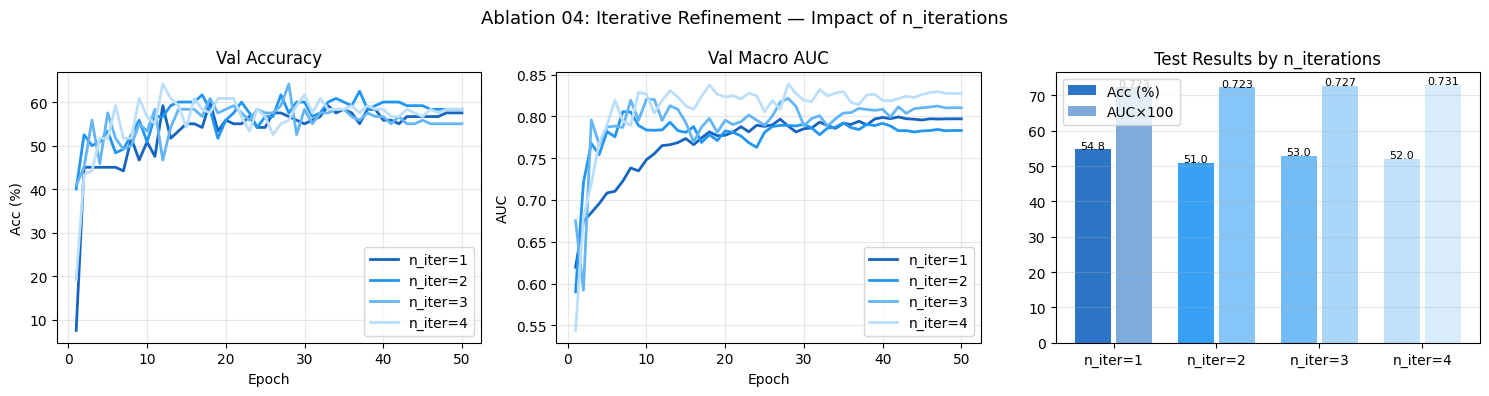

In [ ]:
colors = ["#1565C0","#2196F3","#64B5F6","#BBDEFB"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, n_iter in enumerate(ITER_VARIANTS):
    h  = all_histories[n_iter]
    ep = range(1, len(h["val_acc"])+1)
    axes[0].plot(ep, [a*100 for a in h["val_acc"]], label=f"n_iter={n_iter}", lw=2, color=colors[i])
    axes[1].plot(ep, h["val_auc"],                  label=f"n_iter={n_iter}", lw=2, color=colors[i])

for ax, title, yl in [(axes[0],"Val Accuracy","Acc (%)"),(axes[1],"Val Macro AUC","AUC")]:
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel(yl); ax.legend(); ax.grid(alpha=0.3)

x = np.arange(len(ITER_VARIANTS))
accs = [all_test_results[n]["acc"]*100 for n in ITER_VARIANTS]
aucs = [all_test_results[n]["auc"]*100 for n in ITER_VARIANTS]
axes[2].bar(x-0.2, accs, width=0.35, color=colors, alpha=0.9, label="Acc (%)")
axes[2].bar(x+0.2, aucs, width=0.35, color=colors, alpha=0.55, label="AUC×100")
axes[2].set_xticks(x); axes[2].set_xticklabels([f"n_iter={n}" for n in ITER_VARIANTS])
axes[2].set_title("Test Results by n_iterations"); axes[2].legend(); axes[2].grid(alpha=0.3, axis="y")
for j,(a,u) in enumerate(zip(accs,aucs)):
    axes[2].text(j-0.2, a+0.2, f"{a:.1f}", ha="center", fontsize=8)
    axes[2].text(j+0.2, u+0.2, f"{u/100:.3f}", ha="center", fontsize=8)

plt.suptitle("Ablation 04: Iterative Refinement — Impact of n_iterations", fontsize=13)
plt.tight_layout()
plt.savefig(f"{ABLATION_DIR}/ablation04_results.png", dpi=150, bbox_inches="tight")
plt.show()
